# From Mongo to Oracle 26ai: an agent harness in fifteen cells

Every technological cycle, organisations migrate. Mainframe to relational. On-prem to cloud. Now the move is to systems that are built for AI workloads, with vectors and JSON and SQL all sitting in the same engine. And as Michelle Maula at Oracle keeps pointing out: migration is still the number-one issue customers raise on Oracle Database. Hard to design, harder to verify, full of surprise.

In this notebook we build a small migration agent that moves a synthetic product reviews corpus from MongoDB into Oracle AI Database 26ai. We preserve the AI workload (the vectors keep working) and we gain new capabilities (SQL aggregation through JSON Relational Duality). The whole thing fits in fifteen cells.

## What you will learn

1. How an agent harness composes nine layers around a model.
2. How a seven-stage state machine drives the migration loop.
3. How Oracle's own published migration playbook steers the agent toward Duality.
4. How to do a vector-parity check (the same RAG question still works after the move).
5. How JSON Relational Duality unlocks SQL aggregation without copying the data.

## Prerequisites

| Component | Version | Why |
|---|---|---|
| Python | >= 3.11 | sentence-transformers and modern syntax |
| Podman or Docker | latest | Oracle Database Free Container, MongoDB |
| MongoDB | >= 7.0 | source corpus |
| Oracle AI Database 26ai Free | latest | target with VECTOR + Duality |
| Model API key | any | optional; this notebook does not require an LLM call |

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# We pin nothing tightly: this notebook follows pyproject.toml's floors.
# sentence-transformers downloads a ~80 MB model on first use; cached after.
# nest_asyncio lets asyncio.run() work inside Jupyter's existing event loop.

%pip install -q oracledb pymongo sentence-transformers numpy python-dotenv \
    langchain-oracledb pandas matplotlib nest_asyncio

print("Dependencies ready.")


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencies ready.


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Every variable the agent needs, in one place. We print non-secret values
# so you can see exactly what the agent is being told to talk to.
#
# Oracle AI Developer Hub layout:
#   apps/oracle-data-migration-harness/          <- app code and .env
#   notebooks/oracle_data_migration_harness...   <- this notebook

import os
import sys
from pathlib import Path

APP_DIR = Path("..") / "apps" / "oracle-data-migration-harness"
sys.path.insert(0, str(APP_DIR.resolve()))

from dotenv import load_dotenv

load_dotenv(APP_DIR / ".env")

config = {
    "ORACLE_USER":     os.getenv("ORACLE_USER", "migration_agent"),
    "ORACLE_PASSWORD": "***" if os.getenv("ORACLE_PASSWORD") else None,
    "ORACLE_DSN":      os.getenv("ORACLE_DSN", "localhost:1521/FREEPDB1"),
    "MONGO_URI":       os.getenv("MONGO_URI", "mongodb://localhost:27017"),
    "MONGO_DB":        os.getenv("MONGO_DB", "reviews_demo"),
    "EMBEDDING_MODEL": os.getenv("EMBEDDING_MODEL", "sentence-transformers/all-MiniLM-L6-v2"),
    "APP_DIR":         str(APP_DIR),
}
config


ORACLE_USER        = data_migration_harness
ORACLE_PASSWORD    = ***
ORACLE_DSN         = localhost:1521/FREEPDB1
MONGO_URI          = mongodb://localhost:27017
MONGO_DB           = reviews_demo
EMBEDDING_MODEL    = sentence-transformers/all-MiniLM-L6-v2


## The source

MongoDB holds 500 synthetic products. Each product has nested reviews, vendor info, tags, prices. The chatbot you might build on top of this is a normal RAG agent: vector search over the review text, return semantically similar matches.

We confirm we can talk to it.

In [3]:
# ── MongoDB smoke test ────────────────────────────────────────────────────────
from pymongo import MongoClient

client = MongoClient(config["MONGO_URI"])
mdb = client[config["MONGO_DB"]]
products_count = mdb.products.count_documents({})
sample = mdb.products.find_one({"category": "Audio"}, {"_id": 0, "name": 1, "price": 1, "category": 1})
print(f"products in collection: {products_count}")
print(f"sample audio product:   {sample}")

products in collection: 500
sample audio product:   {'name': 'Max Headphones', 'category': 'Audio', 'price': 196.21}


## The target

Oracle AI Database 26ai Free runs in a container locally. The agent will land documents into it, project them into relational tables, build a duality view on top, and add a vector column. We confirm we can talk to it.

In [4]:
# ── Oracle smoke test ─────────────────────────────────────────────────────────
import oracledb

pool = oracledb.create_pool(
    user=config["ORACLE_USER"],
    password=os.getenv("ORACLE_PASSWORD"),
    dsn=config["ORACLE_DSN"],
    min=1, max=4, increment=1,
)

with pool.acquire() as conn:
    cur = conn.cursor()
    cur.execute("SELECT BANNER_FULL FROM V$VERSION WHERE ROWNUM = 1")
    print("connected to:", cur.fetchone()[0].strip())

connected to: Oracle AI Database 26ai Free Release 23.26.1.0.0 - Develop, Learn, and Run for Free
Version 23.26.1.0.0


## The model (optional for this notebook)

The full app uses Oracle Code Assist for chat. This notebook does not call a model anywhere; the demo path is fully deterministic so you can read it without credentials. We sanity-check the embedding model instead, since that is what does the actual semantic work in this build.

In [5]:
# ── Embedding model warm-up ───────────────────────────────────────────────────
# sentence-transformers runs locally; data never leaves the machine.
# First call downloads the model (cached after).

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(config["EMBEDDING_MODEL"])
sanity_vec = model.encode(["wireless headphones"], normalize_embeddings=True)[0]
print(f"model:      {config['EMBEDDING_MODEL']}")
print(f"output dim: {len(sanity_vec)}")
print(f"first 4:    {[round(float(v), 4) for v in sanity_vec[:4]]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

model:      sentence-transformers/all-MiniLM-L6-v2
output dim: 384
first 4:    [-0.0709, 0.042, -0.0327, -0.0181]


## The harness, in one picture

An agent harness is the layers between a model and the world. Richmond at Oracle teaches a canonical nine. Here is how our migration agent maps to them:

| Layer | What it is | What we use |
|---|---|---|
| 1 | Model | Oracle Code Assist (skipped in this notebook) |
| 2 | Instructions | Oracle's published migration skills |
| 3 | Tools | Mongo reader, Oracle landing, Duality, Vector, DBFS |
| 4 | Environment | Oracle Database File System (DBFS) for scratch |
| 5 | Memory | Oracle 26ai with VECTOR columns |
| 6 | Context | An explicit prompt builder per call |
| 7 | Orchestration | A seven-stage Python state machine |
| 8 | Verification | Row counts and content checks |
| 9 | Governance | PII flagging |

The seven stages run in this order:

```
plan -> sample -> translate_schema -> dry_run -> transfer -> verify -> reconcile
```

The interesting beat is `translate_schema`: the agent reads Oracle's own migration playbook, sees that JSON Relational Duality is the recommended approach for new Oracle-target migrations, and applies it. We watch that decision happen in cell `mig-11`.

Diagram, in plain ASCII:

```
+-----------------+        +------------------------+        +--------------------+
| MongoDB         |  agent | seven-stage harness    |  agent | Oracle AI 26ai     |
| products        | -----> | plan, sample, schema,  | -----> | products + reviews |
| (with vectors)  |        | dry_run, transfer,     |        | duality view       |
|                 |        | verify, reconcile      |        | VECTOR(384)        |
+-----------------+        +------------------------+        +--------------------+
```

## Seeding the corpus

If you ran the project's `make seed` already, this cell is a no-op. If not, it generates 500 products and writes them to MongoDB.

In [6]:
# ── Seed (idempotent) ─────────────────────────────────────────────────────────
# Re-runs are safe; we always drop and re-insert.

from scripts.seed_mongo import generate

mdb.products.drop()
products = generate()
mdb.products.insert_many(products)
print(f"inserted {mdb.products.count_documents({})} products into reviews_demo.products")

inserted 500 products into reviews_demo.products


## Embedding the corpus on the Mongo side

We pick the highest-rated review per product, embed the text, and write the vector back into the document. Same model that runs on the Oracle side (parity matters: we want the chatbot to find the same answers after migration).

In [7]:
# ── Embed reviews ─────────────────────────────────────────────────────────────
from pymongo import UpdateOne

texts, review_texts, ids = [], [], []
for doc in mdb.products.find({}):
    if not doc.get("reviews"):
        continue
    review = max(doc["reviews"], key=lambda r: r.get("rating", 0))
    texts.append(f"{doc['name']}: {review['text']}")
    review_texts.append(review["text"])
    ids.append(doc["_id"])

embeddings = model.encode(texts, batch_size=64, show_progress_bar=False, normalize_embeddings=True)
ops = [
    UpdateOne(
        {"_id": _id},
        {"$set": {"review_text": rt, "review_embedding": emb.tolist()}},
    )
    for _id, rt, emb in zip(ids, review_texts, embeddings)
]
result = mdb.products.bulk_write(ops, ordered=False)
print(f"embedded {result.modified_count} products with 384-dim vectors")

embedded 500 products with 384-dim vectors


## Vector search on Mongo (before)

We ask the question we will ask again later, after migration. The chatbot does fine: it finds reviews that mean something similar to the query.

In [8]:
# ── Vector search on Mongo (local cosine fallback; no Atlas needed) ──────────
import numpy as np

QUESTION = "What do customers say about wireless headphones?"
qv = model.encode([QUESTION], normalize_embeddings=True)[0]

docs = list(mdb.products.find(
    {"review_embedding": {"$exists": True}},
    {"name": 1, "category": 1, "review_text": 1, "review_embedding": 1},
))
qv_np = np.array(qv)
scored = []
for d in docs:
    ev = np.array(d["review_embedding"])
    score = float(np.dot(qv_np, ev) / (np.linalg.norm(qv_np) * np.linalg.norm(ev)))
    scored.append((score, d["name"], d["category"], d["review_text"]))
scored.sort(reverse=True)

print(f'Q: {QUESTION}')
for s, name, cat, text in scored[:3]:
    print(f"  {s:.3f}  {name} ({cat}): {text}")

Q: What do customers say about wireless headphones?
  0.594  Classic Headphones (Audio): Great headphones, exceeded expectations.
  0.586  Lite Headphones (Audio): Customer service was excellent when my headphones arrived damaged.
  0.585  Mini Headphones (Audio): Customer service was excellent when my headphones arrived damaged.


## The harness runs

This is the load-bearing cell. We invoke the seven-stage state machine and print each event. Watch the `translate_schema` event: the agent reads Oracle's own migration playbook (vendored from `oracle/skills`), notices that JSON Relational Duality is the recommended approach, and applies it. That decision is the talk's load-bearing point.

In [9]:
# ── Run the seven-stage state machine ─────────────────────────────────────────
# Jupyter already runs an event loop, so nest_asyncio patches it to allow
# a second asyncio.run() call from inside a notebook cell.
import asyncio
import nest_asyncio
from data_migration_harness.orchestrator import run_migration

nest_asyncio.apply()

async def collect():
    out = []
    async for event in run_migration():
        out.append(event)
        print(f'[{event["stage"]:18s}] {event["status"]:9s} -> {event["narration"]}')
    return out

events = asyncio.run(collect())
print(f"\n{len(events)} events emitted, ending with stage='{events[-1]['stage']}'")

[plan              ] started   -> Building the run manifest
[plan              ] completed -> Plan ready: Mongo products to Oracle products with duality view


[sample            ] started   -> Inspecting a slice of the Mongo collection
[sample            ] completed -> Sampled 5 documents


[translate_schema  ] started   -> Reading Oracle's migration playbook
[translate_schema  ] completed -> Playbook recommends JSON Relational Duality. Generating duality view DDL now.


[dry_run           ] started   -> Rehearsing on 50 documents
[dry_run           ] completed -> Dry run landed 50 docs successfully


[transfer          ] started   -> Moving the full corpus


[transfer          ] completed -> Transferred 500 documents and built the duality view


[verify            ] started   -> Comparing row counts and content samples
[verify            ] completed -> Counts match, content checks pass


[reconcile         ] started   -> Recording any gaps
[reconcile         ] completed -> No gaps recorded


[unlocked          ] completed -> Right pane ready

15 events emitted, ending with stage='unlocked'


## Vector search on Oracle (after, the parity check)

Same question. Now the chatbot is talking to Oracle. We expect the same kind of answer: reviews that mean something similar. If we get parity here, the AI workload survived the migration.

In [10]:
# ── Embed query, then vector_distance via Oracle ──────────────────────────────
import array

qv_oracle = model.encode([QUESTION], normalize_embeddings=True)[0].tolist()
qv_arr = array.array("f", qv_oracle)

with pool.acquire() as conn:
    cur = conn.cursor()
    cur.execute("""
        SELECT name, category, review_text,
               VECTOR_DISTANCE(review_embedding, :qv, COSINE) AS distance
        FROM products
        WHERE review_embedding IS NOT NULL
        ORDER BY distance
        FETCH FIRST 3 ROWS ONLY
    """, {"qv": qv_arr})
    rows = cur.fetchall()

print(f'Q: {QUESTION}')
for name, cat, text, dist in rows:
    print(f"  {dist:.3f}  {name} ({cat}): {text}")

Q: What do customers say about wireless headphones?
  0.406  Classic Headphones (Audio): Great headphones, exceeded expectations.
  0.414  Lite Headphones (Audio): Customer service was excellent when my headphones arrived damaged.
  0.415  Mini Headphones (Audio): Customer service was excellent when my headphones arrived damaged.


## Duality unlocks the SQL question

Here is the question MongoDB struggled with: "average rating by category, products under £50, verified buyers, last 90 days." On Mongo, that is an aggregation pipeline that has to dig around inside every document. On Oracle, the same data is also a relational table (the duality view exposes both shapes), and the SQL is one paragraph. We chart the result.

/var/folders/gv/54hrngtj1md98fyh5myfmmd40000gp/T/ipykernel_67633/4067382069.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(DEMO_AGGREGATION, conn, params={"max_price": 50.0})


,CATEGORY,AVG_RATING,REVIEW_COUNT
0,Wearables,4.09,58
1,Audio,3.98,49
2,Office,3.89,76
3,Kitchen,3.85,85
4,Outdoor,3.61,38
5,Home,3.54,39


Matplotlib is building the font cache; this may take a moment.


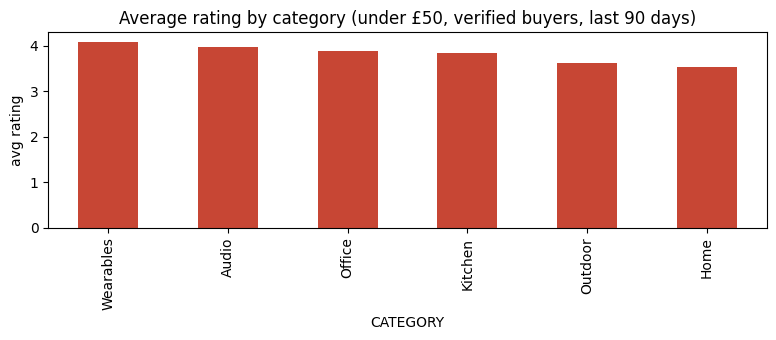

In [11]:
# ── Aggregate via the duality-projected relational tables ─────────────────────
import pandas as pd

DEMO_AGGREGATION = """
SELECT p.category,
       ROUND(AVG(r.rating), 2) AS avg_rating,
       COUNT(*) AS review_count
FROM products p
JOIN reviews r ON r.product_id = p.product_id
WHERE p.price < :max_price
  AND r.verified_buyer = 1
  AND r.posted_at > SYSDATE - 90
GROUP BY p.category
ORDER BY avg_rating DESC
"""

with pool.acquire() as conn:
    df = pd.read_sql(DEMO_AGGREGATION, conn, params={"max_price": 50.0})

display(df)

ax = df.plot.bar(x="CATEGORY", y="AVG_RATING", color="#C74634", figsize=(8, 3.5), legend=False)
ax.set_ylabel("avg rating")
ax.set_title("Average rating by category (under £50, verified buyers, last 90 days)")
ax.figure.tight_layout()

## What got stored, and where

The audit trail. Every stage wrote a small artefact to Oracle's Database File System (DBFS scratchpad). Reading them back is what an operator would do during a post-migration review.

In [12]:
# ── Audit trail ───────────────────────────────────────────────────────────────
with pool.acquire() as conn:
    cur = conn.cursor()
    cur.execute("SELECT path, written_at, LENGTH(content) AS bytes FROM dbfs_scratch ORDER BY written_at")
    rows = cur.fetchall()

print(f"{'path':<28} {'written_at':<22} {'bytes':>8}")
for path, ts, n in rows:
    print(f"{path:<28} {str(ts):<22} {n:>8}")

path                         written_at                bytes
run/manifest.json            2026-05-07 17:46:33.520833      101
run/sample.json              2026-05-07 17:46:33.841526      178
run/schema_decision.md       2026-05-07 17:46:34.145789      138
run/reconcile.json           2026-05-07 17:46:35.920892       36


## What just happened, and what comes next

We did three things:

1. The harness moved 500 documents and their vectors from Mongo to Oracle.
2. The chatbot still answers semantic questions on the new substrate (vector parity).
3. The same data is now queryable as relational rows through a Duality view, which lets us answer aggregation questions cleanly.

Two layers we did not exercise in this notebook:

- **Oracle True Cache** for hot read scaling. Lives at Layer 4 alongside DBFS.
- **GraalPy** for safe in-database code execution. Lives at Layer 4.

Both are real Oracle primitives. Richmond covers them in the workshop that follows the SuperFans talk.

If you cloned the Oracle AI Developer Hub, run the live app from `apps/oracle-data-migration-harness` with `make app` and `make ui` to get the split-screen RAG chatbot. The notebook is the slow-motion version, written for reading.